In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.simplefilter("ignore")

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)

In [3]:
def load():
    data = pd.read_csv("/kaggle/input/datasets/imakash3011/online-shoppers-purchasing-intention-dataset/online_shoppers_intention.csv")
    return data

In [4]:
df = load()

# Exploratory Data Analysis (EDA)

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

# Explanation of columns


**Administrative:** The number of pages of this type (administrative) that the user visited.

**Administrative_Duration:** This is the amount of time spent in this category of pages.

**Informational:** This is the number of pages of this type (informational) that the user visited.

**Informational_Duration:** This is the amount of time spent in this category of pages.

**ProductRelated:** This is the number of pages of this type (product related) that the user visited.

**ProductRelated_Duration:** This is the amount of time spent in this category of pages.

**BounceRates:** The percentage of visitors who enter the website through that page and exit without triggering any additional

**ExitRates:** The percentage of pageviews on the website that end at that specific page.

**PageValues:** The average value of the page averaged over the value of the target page and/or the completion of an eCommerce

**SpecialDay:** This value represents the closeness of the browsing date to special days or holidays

**Month**: Month visited (Feb, Mar, May, Nov, etc.)

**OperatingSystems**: User's operating system ID.

**Browser**: Browser ID

**Region**: Region ID

**TrafficType**: Organic search, Advertising, Direct login, Referral, etc.

**VisitorType**: Returning Visitor, New Visitor, Other

**Weekend**: Is the visit on the weekend? (True / False)

**Revenue** -> target column



In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [9]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

No missing value

In [10]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

sold: 10422

unsold: 1908

In [11]:
df.shape

(12330, 18)

In [12]:
def grab_col_names(dataframe, cat_th = 10, car_th = 20):
    
 cat_cols = [col for col in dataframe.columns if dataframe[col].dtype in ["bool", "object", "category"]]
             
 num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                dataframe[col].dtype in ["int64", "float64"]]
 cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                dataframe[col].dtype in  ["object","category"]]
 cat_cols = cat_cols + num_but_cat
 cat_cols = [col for col in cat_cols if col not in cat_but_car]

 num_cols = [col for col in dataframe.columns if dataframe[col].dtype in ["int64","float64"] and col not in num_but_cat]


 print(f"Observations: {dataframe.shape[0]}")
 print(f"Variables: {dataframe.shape[1]}")
 print(f"cat_cols: {len(cat_cols)}")
 print(f"num_cols: {len(num_cols)}")
 print(f"num_but_cat: {len(num_but_cat)}")
 print(f"cat_but_car: {len(cat_but_car)}")
 return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)


Observations: 12330
Variables: 18
cat_cols: 7
num_cols: 11
num_but_cat: 3
cat_but_car: 0


In [13]:
cat_cols

['Month',
 'VisitorType',
 'Weekend',
 'Revenue',
 'SpecialDay',
 'OperatingSystems',
 'Region']

In [14]:
num_cols

['Administrative',
 'Administrative_Duration',
 'Informational',
 'Informational_Duration',
 'ProductRelated',
 'ProductRelated_Duration',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'Browser',
 'TrafficType']

# Outlier Detection

In [15]:
def outlier_thresholds (dataframe, col_name, q1 = 0.25, q3=0.75):
    quartile1=dataframe[col_name].quantile(q1)
    quartile3=dataframe[col_name].quantile(q3)
    iqr = quartile3 - quartile1
    up_limit = quartile3 + iqr*1.5
    low_limit = quartile1 - 1.5 * iqr
    return low_limit, up_limit
    

In [16]:
def check_outlier_count(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    
    outliers = dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)]
    count = outliers.shape[0]

    return count

In [17]:
for col in num_cols:
    count = check_outlier_count(df, col)
    print(f"{col} - {count} outliers")
   

Administrative - 404 outliers
Administrative_Duration - 1172 outliers
Informational - 2631 outliers
Informational_Duration - 2405 outliers
ProductRelated - 987 outliers
ProductRelated_Duration - 961 outliers
BounceRates - 1551 outliers
ExitRates - 1099 outliers
PageValues - 2730 outliers
Browser - 4369 outliers
TrafficType - 2101 outliers


There are outliers almost all of columns

In [18]:
#Numerical variable analysis

count    12330.000000
mean         2.315166
std          3.321784
min          0.000000
5%           0.000000
10%          0.000000
20%          0.000000
30%          0.000000
40%          0.000000
50%          1.000000
60%          2.000000
70%          3.000000
80%          4.000000
90%          7.000000
95%          9.000000
99%         14.000000
max         27.000000
Name: Administrative, dtype: float64


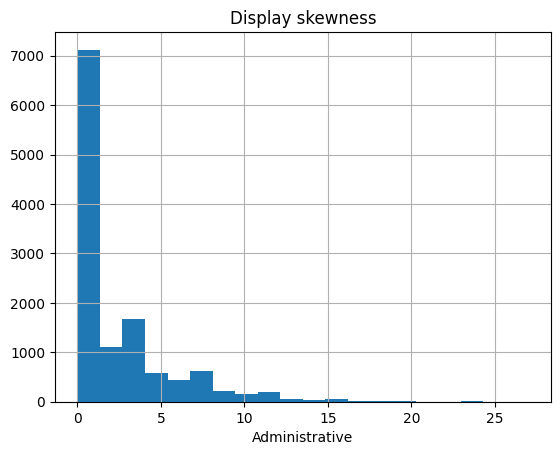

count    12330.000000
mean        80.818611
std        176.779107
min          0.000000
5%           0.000000
10%          0.000000
20%          0.000000
30%          0.000000
40%          0.000000
50%          7.500000
60%         37.000000
70%         71.200000
80%        121.425000
90%        224.887500
95%        348.266369
99%        830.587041
max       3398.750000
Name: Administrative_Duration, dtype: float64


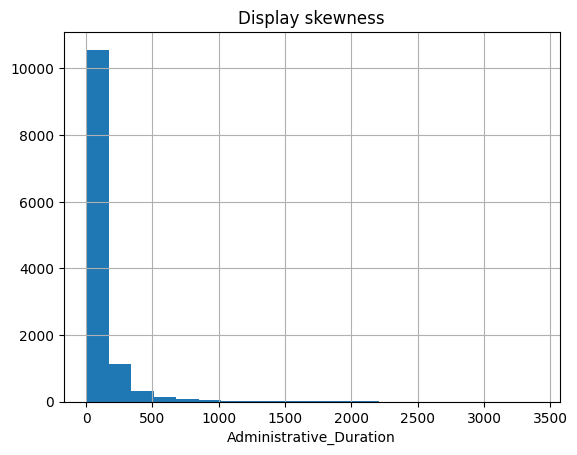

count    12330.000000
mean         0.503569
std          1.270156
min          0.000000
5%           0.000000
10%          0.000000
20%          0.000000
30%          0.000000
40%          0.000000
50%          0.000000
60%          0.000000
70%          0.000000
80%          1.000000
90%          2.000000
95%          3.000000
99%          6.000000
max         24.000000
Name: Informational, dtype: float64


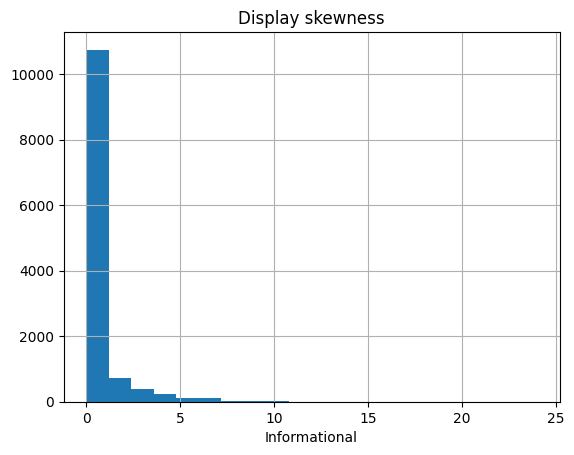

count    12330.000000
mean        34.472398
std        140.749294
min          0.000000
5%           0.000000
10%          0.000000
20%          0.000000
30%          0.000000
40%          0.000000
50%          0.000000
60%          0.000000
70%          0.000000
80%          0.000000
90%         72.000000
95%        195.000000
99%        716.390000
max       2549.375000
Name: Informational_Duration, dtype: float64


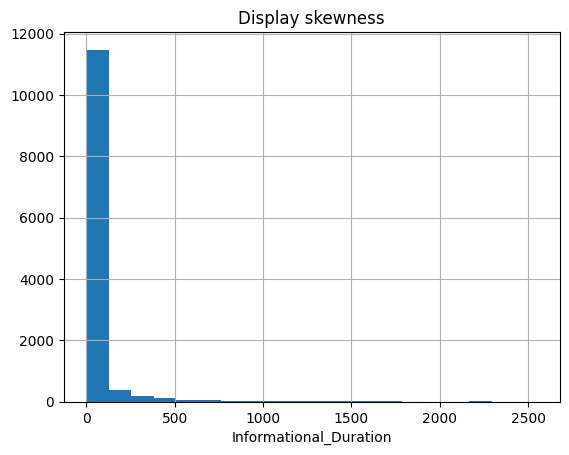

count    12330.000000
mean        31.731468
std         44.475503
min          0.000000
5%           1.000000
10%          3.000000
20%          6.000000
30%          9.000000
40%         13.000000
50%         18.000000
60%         24.000000
70%         32.000000
80%         45.000000
90%         74.000000
95%        109.000000
99%        221.000000
max        705.000000
Name: ProductRelated, dtype: float64


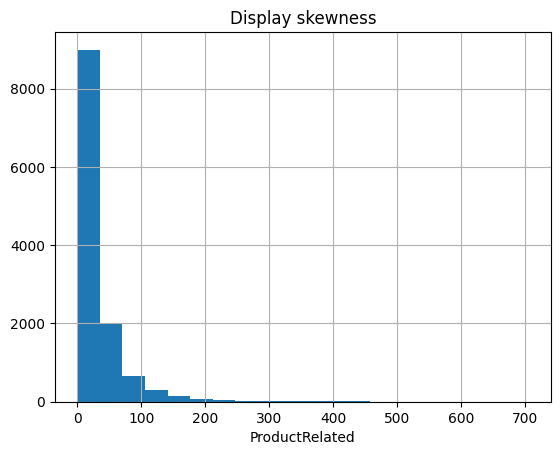

count    12330.000000
mean      1194.746220
std       1913.669288
min          0.000000
5%           0.000000
10%         36.000000
20%        129.000000
30%        246.980000
40%        402.117216
50%        598.936905
60%        852.000000
70%       1227.014167
80%       1775.928667
90%       2877.863333
95%       4300.289077
99%       8701.142697
max      63973.522230
Name: ProductRelated_Duration, dtype: float64


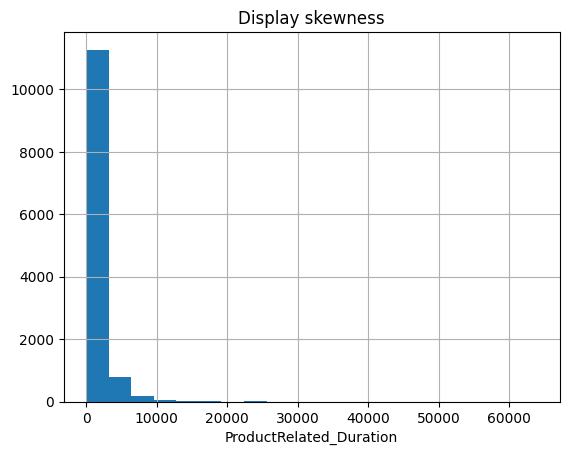

count    12330.000000
mean         0.022191
std          0.048488
min          0.000000
5%           0.000000
10%          0.000000
20%          0.000000
30%          0.000000
40%          0.000000
50%          0.003112
60%          0.007143
70%          0.012859
80%          0.023077
90%          0.058197
95%          0.200000
99%          0.200000
max          0.200000
Name: BounceRates, dtype: float64


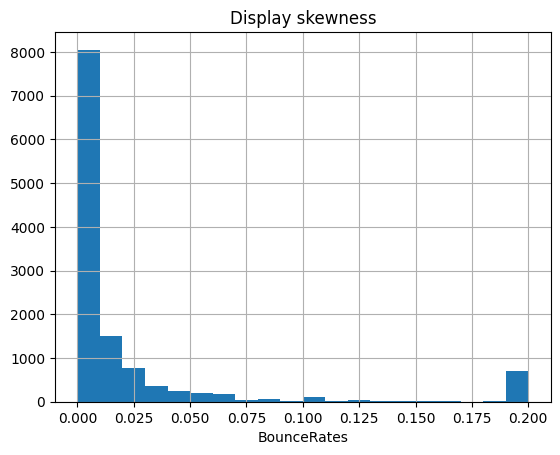

count    12330.000000
mean         0.043073
std          0.048597
min          0.000000
5%           0.004568
10%          0.007449
20%          0.012071
30%          0.016216
40%          0.020513
50%          0.025156
60%          0.032871
70%          0.041270
80%          0.058333
90%          0.100000
95%          0.200000
99%          0.200000
max          0.200000
Name: ExitRates, dtype: float64


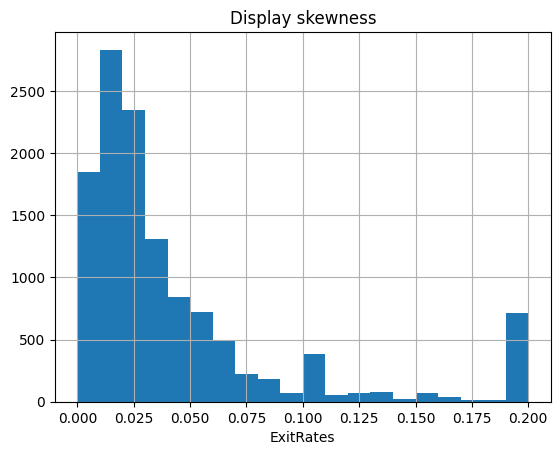

count    12330.000000
mean         5.889258
std         18.568437
min          0.000000
5%           0.000000
10%          0.000000
20%          0.000000
30%          0.000000
40%          0.000000
50%          0.000000
60%          0.000000
70%          0.000000
80%          3.060078
90%         18.855502
95%         38.160528
99%         85.498490
max        361.763742
Name: PageValues, dtype: float64


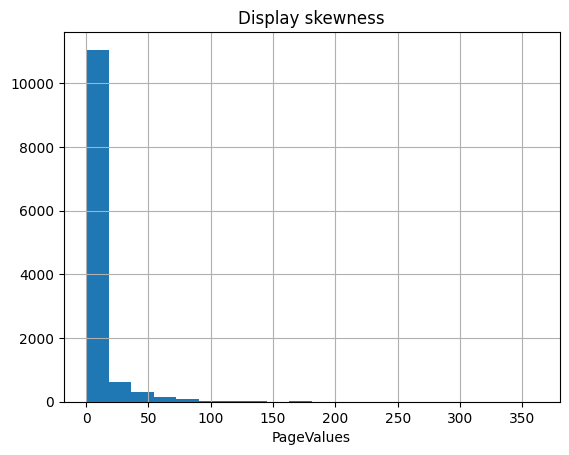

count    12330.000000
mean         2.357097
std          1.717277
min          1.000000
5%           1.000000
10%          1.000000
20%          2.000000
30%          2.000000
40%          2.000000
50%          2.000000
60%          2.000000
70%          2.000000
80%          2.000000
90%          4.000000
95%          5.000000
99%         10.000000
max         13.000000
Name: Browser, dtype: float64


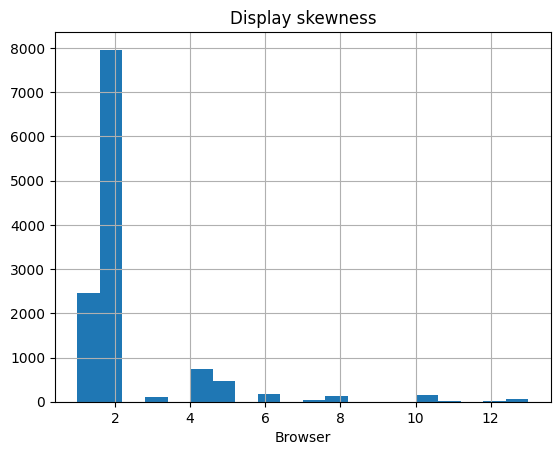

count    12330.000000
mean         4.069586
std          4.025169
min          1.000000
5%           1.000000
10%          1.000000
20%          2.000000
30%          2.000000
40%          2.000000
50%          2.000000
60%          3.000000
70%          4.000000
80%          6.000000
90%         11.000000
95%         13.000000
99%         20.000000
max         20.000000
Name: TrafficType, dtype: float64


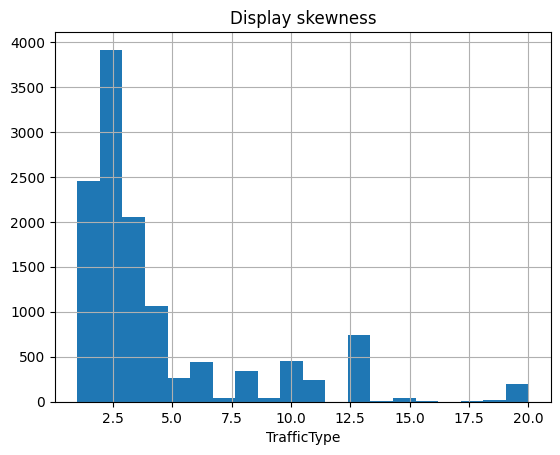

In [19]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title("Display skewness")
        plt.show()

for col in num_cols:
    num_summary(df, col, plot=True)

# Log Transformation

In [20]:
skew_cols = [
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "PageValues"
]

for col in skew_cols:
    df[col] = np.log1p(df[col])

# Encoding

In [21]:
#Label Encoding

In [22]:
def label_encoder(dataframe, binary_col):
    labelencoder = LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe

binary_cols = [col for col in df.columns if df[col].dtypes in ["bool"] and df[col].nunique() == 2]
binary_cols

for col in binary_cols:
    df = label_encoder(df, col)

In [23]:
#Updating cat cols
cat_cols = [col for col in cat_cols if col not in binary_cols and col not in ["Revenue"]]

In [24]:
cat_cols

['Month', 'VisitorType', 'SpecialDay', 'OperatingSystems', 'Region']

In [25]:
#OneHot encoding

In [26]:
y = df["Revenue"].astype(int)
X = df.drop("Revenue", axis=1)

In [27]:
categorical_columns = ["Month", "VisitorType"]
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

In [28]:
train_columns = X.columns.tolist()

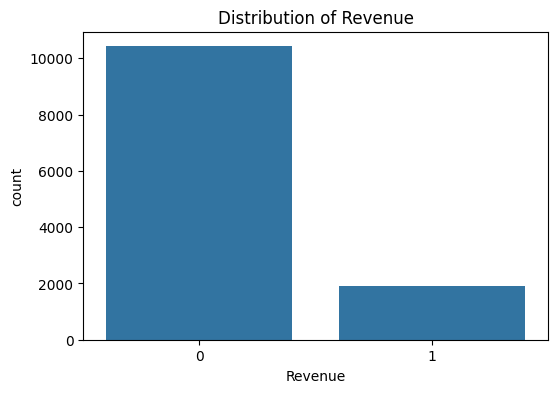

In [29]:
#Revenue distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Revenue", data=df)
plt.title("Distribution of Revenue")
plt.show()

1: Sold

0: Unsold

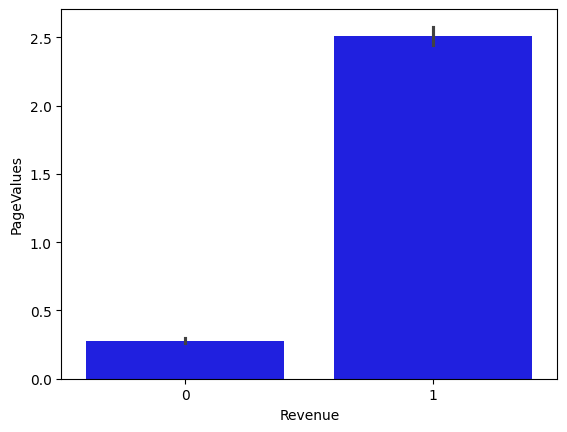

In [30]:
# Relationship between purchasing decision and PageValues

sns.barplot(y="PageValues", x="Revenue", data=df, color="blue")
plt.show()

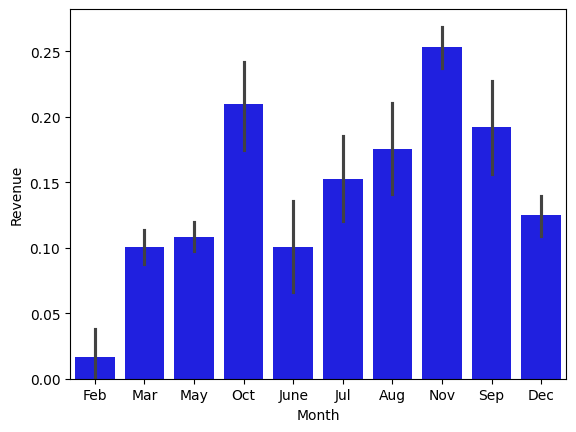

In [31]:
# Relationship between purchasing decision and month

sns.barplot(x="Month", y="Revenue", data=df, color="blue")
plt.show()

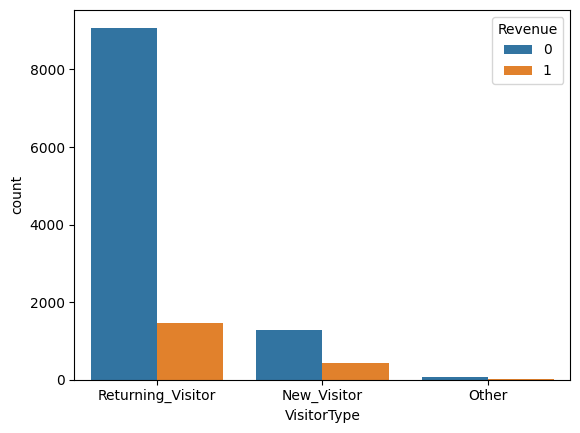

In [32]:
#Relationship between purchasing decision and visitor type
sns.countplot(x="VisitorType", hue="Revenue", data=df)
plt.show()

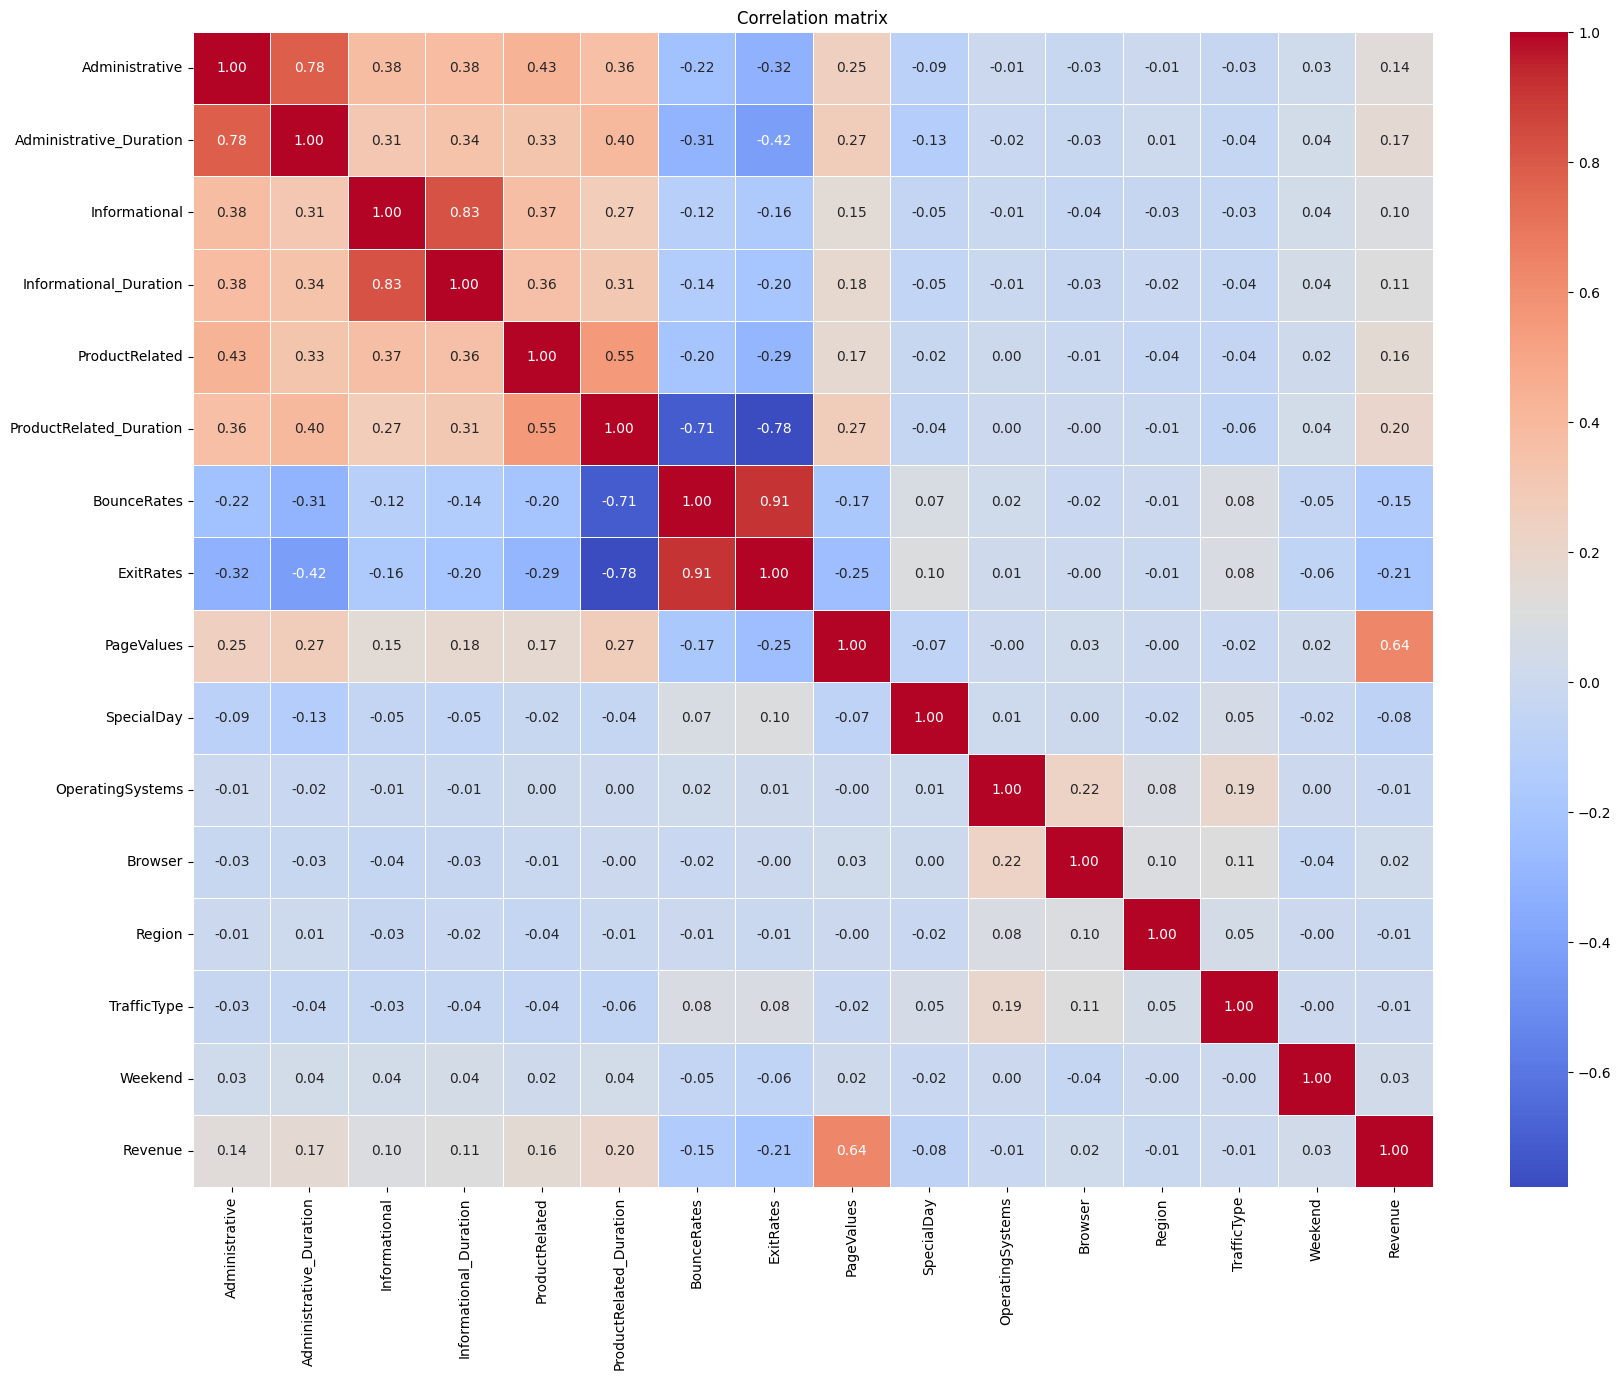

In [33]:
#Correlation Analysis
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(20,15))
corr_matrix=numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",
           fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

# Train Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
    random_state=42, stratify=y
)

# Scaling

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
* Logistic Regression
* XGBoost

In [36]:
lr =LogisticRegression()
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [37]:
y_pred = lr.predict(X_test_scaled)

# Model Evaluation

In [38]:
print(f"Accuracy score: {round(accuracy_score(y_test, y_pred), 2)}")
print(f"Recall score: {round(recall_score(y_test, y_pred), 2)}")
print(f"F1 score: {round(f1_score(y_test, y_pred), 2)}")
print(f"Precision score: {round(precision_score(y_test, y_pred), 2)}")
print("Confusion_matrix", confusion_matrix(y_test, y_pred))

Accuracy score: 0.9
Recall score: 0.55
F1 score: 0.62
Precision score: 0.71
Confusion_matrix [[2000   84]
 [ 172  210]]


# Hyperparameter Tuning

In [39]:
model = LogisticRegression(max_iter=5000)

In [40]:
penalty = ["l1","l2"]
c_values = [0.1, 1, 10]
solver = ["liblinear", "saga"]

In [41]:
params = dict(penalty=penalty, C=c_values, solver=solver)

In [42]:
params

{'penalty': ['l1', 'l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear', 'saga']}

In [43]:
#grid search cv

In [44]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [45]:
cv = StratifiedKFold()

In [46]:
grid = GridSearchCV(estimator = model, param_grid = params, cv=cv,
                   scoring="accuracy", n_jobs=-1)

In [47]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(max_iter=5000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [48]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [49]:
grid.best_score_

np.float64(0.8981144024451803)

In [50]:
y_pred = grid.predict(X_test_scaled)

In [51]:
print(f"Accuracy score: {round(accuracy_score(y_test, y_pred), 2)}")
print(f"Recall score: {round(recall_score(y_test, y_pred), 2)}")
print(f"F1 score: {round(f1_score(y_test, y_pred), 2)}")
print(f"Precision score: {round(precision_score(y_test, y_pred), 2)}")
print("Confusion_matrix", confusion_matrix(y_test, y_pred))

Accuracy score: 0.89
Recall score: 0.55
F1 score: 0.62
Precision score: 0.71
Confusion_matrix [[1997   87]
 [ 173  209]]


In [52]:
#Training with XGBoost

from xgboost import XGBClassifier

In [53]:
xgb = XGBClassifier(n_estimators=2000, random_state=0, learning_rate = 0.02)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [54]:
print(f"Accuracy score: {round(accuracy_score(y_test, y_pred), 2)}")
print(f"Recall score: {round(recall_score(y_test, y_pred), 2)}")
print(f"F1 score: {round(f1_score(y_test, y_pred), 2)}")
print(f"Precision score: {round(precision_score(y_test, y_pred), 2)}")
print("Confusion_matrix", confusion_matrix(y_test, y_pred))

Accuracy score: 0.9
Recall score: 0.6
F1 score: 0.64
Precision score: 0.7
Confusion_matrix [[1987   97]
 [ 154  228]]


# Hyperparameter Tuning

In [55]:
from sklearn.model_selection import RandomizedSearchCV

base = XGBClassifier(
    n_estimators=1500,
    eval_metric="logloss",
    random_state=42
)

param_dist={
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1]
}

rs = RandomizedSearchCV(
    base, param_distributions=param_dist,
    n_iter=30, scoring="roc_auc", cv=5,
    n_jobs=-1, random_state=42
)

rs.fit(X_train, y_train)

best_xgb = rs.best_estimator_
print(rs.best_params_)



{'subsample': 1.0, 'reg_lambda': 2, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 2, 'colsample_bytree': 0.7}


# Model Evaluating

In [56]:
from sklearn.model_selection import cross_val_score

acc_scores = cross_val_score(
    rs.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Accuracy:", acc_scores.mean())

CV Accuracy: 0.9065288596869092


In [57]:
print(f"Accuracy score: {round(accuracy_score(y_test, y_pred), 2)}")
print(f"Recall score: {round(recall_score(y_test, y_pred), 2)}")
print(f"F1 score: {round(f1_score(y_test, y_pred), 2)}")
print(f"Precision score: {round(precision_score(y_test, y_pred), 2)}")
print("Confusion_matrix", confusion_matrix(y_test, y_pred))

Accuracy score: 0.9
Recall score: 0.6
F1 score: 0.64
Precision score: 0.7
Confusion_matrix [[1987   97]
 [ 154  228]]


# Model Decision
To predict the purchasing decision(0,1) of online shoppers, XGBClassifier model is decided.

# Saving Model

In [58]:
import pickle

with open("purchase_xgb_scaled_complete.pkl", "wb") as f:
    pickle.dump(
        {
            "model": best_xgb,
            "scaler": scaler,
            "columns": X.columns.tolist(),
            "dummies_cols": ["Month"]
            
        },
        f
    )
print("Saved: purchase_xgb_scaled_complete.pkl")

Saved: purchase_xgb_scaled_complete.pkl


In [59]:
import pandas as pd
df_test = df.drop(columns=["Revenue"])
df_test.to_csv("test_raw.csv", index=False)
print("test_raw.csv created.")
df_test.head()

test_raw.csv created.


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0
1,0,0.0,0,0.0,2,4.174387,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0
3,0,0.0,0,0.0,2,1.299283,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0
4,0,0.0,0,0.0,10,6.443336,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1
